In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import time
import warnings
import os
os.chdir('D:/MY_Learning/matbench-dielectric/notebooks')
warnings.filterwarnings('ignore')

# 加载数据
df = pd.read_csv('../data/dielectric_cleaned.csv')
X = df.drop('n_dielectric', axis=1)
y = np.log1p(df['n_dielectric'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("数据准备完成")
print(f"特征数: {X.shape[1]}")
print(f"训练集: {X_train.shape[0]} 样本")
print(f"测试集: {X_test.shape[0]} 样本")

# 加载 Day 15 的基准模型（用于对比）
try:
    baseline_xgb = joblib.load('../models/day15_xgboost_default.pkl')
    baseline_test_r2 = baseline_xgb.score(X_test, y_test)
    print(f"\n基准模型（Day 15 默认参数）测试集 R²: {baseline_test_r2:.4f}")
except:
    print("\n未找到基准模型，将创建一个")
    baseline_xgb = xgb.XGBRegressor(random_state=42, n_jobs=-1)
    baseline_xgb.fit(X_train, y_train)
    baseline_test_r2 = baseline_xgb.score(X_test, y_test)

数据准备完成
特征数: 135
训练集: 3811 样本
测试集: 953 样本

基准模型（Day 15 默认参数）测试集 R²: 0.6178



实验 1：max_depth 对性能的影响

training max_depth=3...
  Train R²: 0.8708
  Test R²: 0.6171
  Gap: 0.2537
  Time: 0.16s

training max_depth=4...
  Train R²: 0.9485
  Test R²: 0.6148
  Gap: 0.3337
  Time: 0.20s

training max_depth=5...
  Train R²: 0.9832
  Test R²: 0.5935
  Gap: 0.3898
  Time: 0.26s

training max_depth=6...
  Train R²: 0.9929
  Test R²: 0.6178
  Gap: 0.3751
  Time: 0.41s

training max_depth=7...
  Train R²: 0.9960
  Test R²: 0.5650
  Gap: 0.4310
  Time: 0.68s

training max_depth=8...
  Train R²: 0.9968
  Test R²: 0.6430
  Gap: 0.3537
  Time: 0.96s

training max_depth=9...
  Train R²: 0.9969
  Test R²: 0.5984
  Gap: 0.3985
  Time: 1.33s

training max_depth=10...
  Train R²: 0.9970
  Test R²: 0.6170
  Gap: 0.3799
  Time: 1.60s

Best max_depth: 8 (Test R²=0.6430)


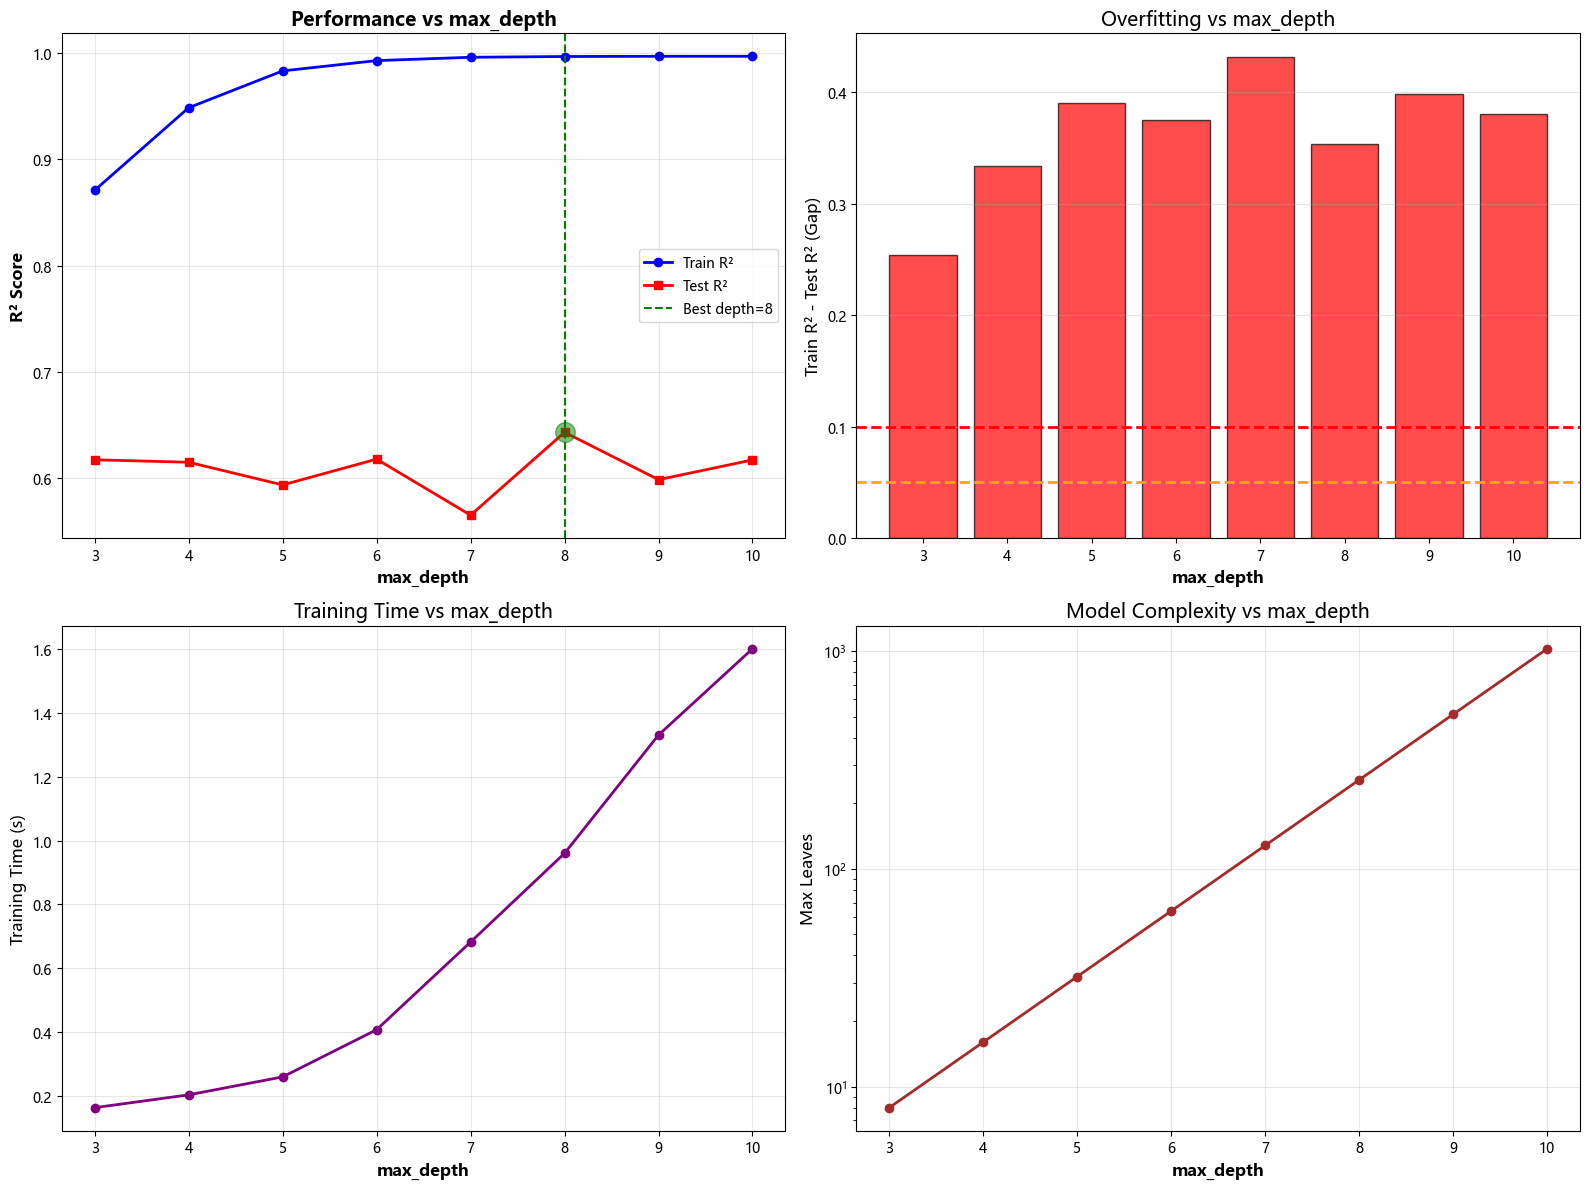


Image saved


In [2]:
# max_depth 的影响
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

print("\n" + "="*70)
print("实验 1：max_depth 对性能的影响")
print("="*70)

depths = [3, 4, 5, 6, 7, 8, 9, 10]
train_scores = []
test_scores = []
train_times = []

for depth in depths:
    print(f"\ntraining max_depth={depth}...")
    
    model = xgb.XGBRegressor(
        max_depth=depth,
        n_estimators=100,
        tree_method='hist',  # 直方图算法，比默认 exact 快 5-10 倍
        random_state=42,
        n_jobs=-1
    )
    
    start = time.time()
    model.fit(X_train, y_train, verbose=False)
    elapsed = time.time() - start
    
    train_r2 = model.score(X_train, y_train)
    test_r2 = model.score(X_test, y_test)
    
    train_scores.append(train_r2)
    test_scores.append(test_r2)
    train_times.append(elapsed)
    
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  Test R²: {test_r2:.4f}")
    print(f"  Gap: {train_r2 - test_r2:.4f}")
    print(f"  Time: {elapsed:.2f}s")

best_depth_idx = np.argmax(test_scores)
best_depth = depths[best_depth_idx]
best_test_r2 = test_scores[best_depth_idx]

print(f"\nBest max_depth: {best_depth} (Test R²={best_test_r2:.4f})")

# 可视化
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax1 = axes[0, 0]
ax1.plot(depths, train_scores, marker='o', linewidth=2, label='Train R²', color='blue')
ax1.plot(depths, test_scores, marker='s', linewidth=2, label='Test R²', color='red')
ax1.axvline(best_depth, color='green', linestyle='--', label=f'Best depth={best_depth}')
ax1.scatter(best_depth, best_test_r2, s=200, color='green', zorder=5, alpha=0.5)
ax1.set_xlabel('max_depth', fontsize=12, fontweight='bold')
ax1.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax1.set_title('Performance vs max_depth', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
gaps = np.array(train_scores) - np.array(test_scores)
colors = ['green' if g < 0.05 else 'orange' if g < 0.10 else 'red' for g in gaps]
ax2.bar(depths, gaps, color=colors, alpha=0.7, edgecolor='black')
ax2.axhline(0.05, color='orange', linestyle='--', linewidth=2)
ax2.axhline(0.10, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('max_depth', fontsize=12, fontweight='bold')
ax2.set_ylabel('Train R² - Test R² (Gap)', fontsize=12)
ax2.set_title('Overfitting vs max_depth', fontsize=14)
ax2.grid(True, alpha=0.3, axis='y')

ax3 = axes[1, 0]
ax3.plot(depths, train_times, marker='o', linewidth=2, color='purple')
ax3.set_xlabel('max_depth', fontsize=12, fontweight='bold')
ax3.set_ylabel('Training Time (s)', fontsize=12)
ax3.set_title('Training Time vs max_depth', fontsize=14)
ax3.grid(True, alpha=0.3)

ax4 = axes[1, 1]
ax4.plot(depths, [2**d for d in depths], marker='o', linewidth=2, color='brown')
ax4.set_xlabel('max_depth', fontsize=12, fontweight='bold')
ax4.set_ylabel('Max Leaves', fontsize=12)
ax4.set_title('Model Complexity vs max_depth', fontsize=14)
ax4.set_yscale('log')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/day16_xgb_max_depth_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nImage saved")


实验 2：subsample 对性能的影响

训练 subsample=0.5...
  训练集 R²: 0.9900
  测试集 R²: 0.5946
  差距: 0.3954

训练 subsample=0.6...
  训练集 R²: 0.9929
  测试集 R²: 0.5830
  差距: 0.4100

训练 subsample=0.7...
  训练集 R²: 0.9947
  测试集 R²: 0.5950
  差距: 0.3997

训练 subsample=0.8...
  训练集 R²: 0.9953
  测试集 R²: 0.6135
  差距: 0.3818

训练 subsample=0.9...
  训练集 R²: 0.9962
  测试集 R²: 0.6293
  差距: 0.3670

训练 subsample=1.0...
  训练集 R²: 0.9968
  测试集 R²: 0.6430
  差距: 0.3537

最佳 subsample: 1.0 (测试集 R²=0.6430)


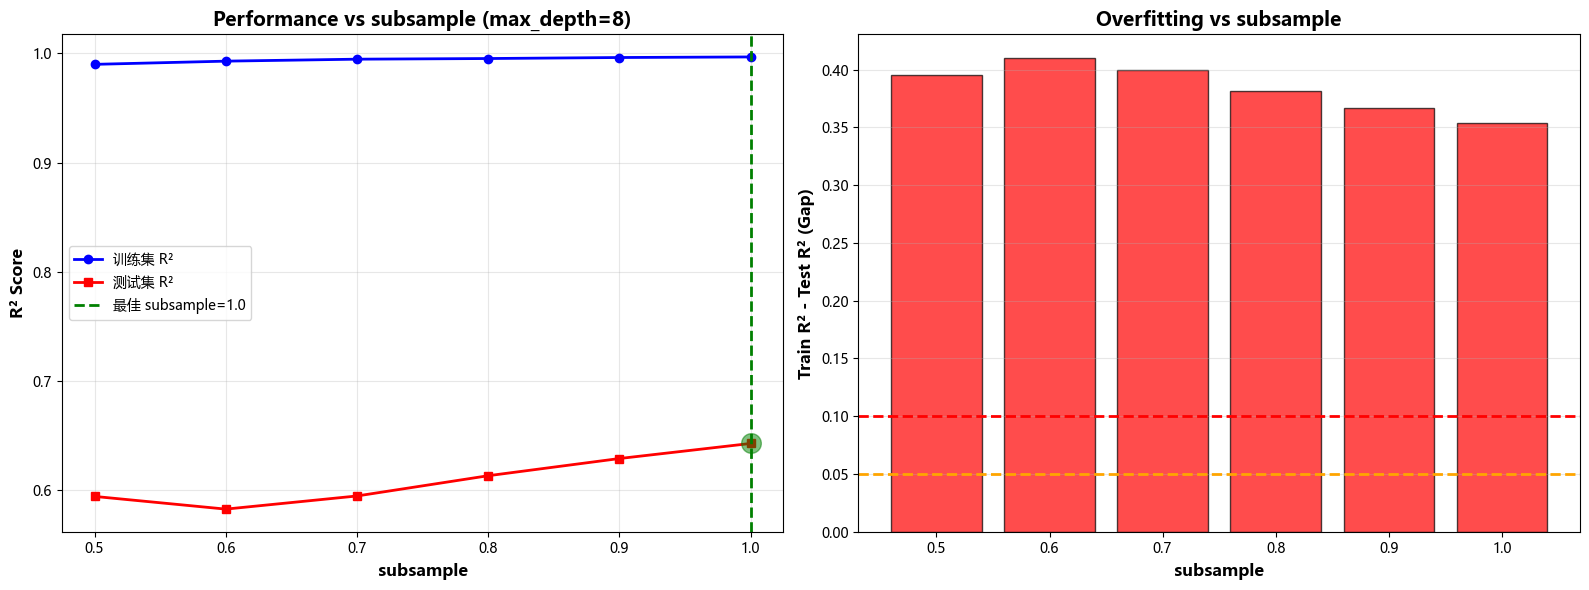


✓ subsample 分析图已保存


In [3]:
# sub sample的影响
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
print("\n" + "="*70)
print("实验 2：subsample 对性能的影响")
print("="*70)

# 固定最佳 max_depth，测试不同的 subsample
subsamples = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
subsample_train_scores = []
subsample_test_scores = []

for sub in subsamples:
    print(f"\n训练 subsample={sub}...")
    
    model = xgb.XGBRegressor(
        max_depth=best_depth,
        subsample=sub,
        n_estimators=100,
        tree_method='hist',  # 直方图算法，快 5-10 倍
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train, verbose=False)
    
    train_r2 = model.score(X_train, y_train)
    test_r2 = model.score(X_test, y_test)
    
    subsample_train_scores.append(train_r2)
    subsample_test_scores.append(test_r2)
    
    print(f"  训练集 R²: {train_r2:.4f}")
    print(f"  测试集 R²: {test_r2:.4f}")
    print(f"  差距: {train_r2 - test_r2:.4f}")

# 找到最佳 subsample
best_subsample_idx = np.argmax(subsample_test_scores)
best_subsample = subsamples[best_subsample_idx]
best_subsample_test_r2 = subsample_test_scores[best_subsample_idx]

print(f"\n最佳 subsample: {best_subsample} (测试集 R²={best_subsample_test_r2:.4f})")

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：R² vs subsample
ax1 = axes[0]
ax1.plot(subsamples, subsample_train_scores, marker='o', linewidth=2, 
         label='训练集 R²', color='blue')
ax1.plot(subsamples, subsample_test_scores, marker='s', linewidth=2, 
         label='测试集 R²', color='red')
ax1.axvline(best_subsample, color='green', linestyle='--', linewidth=2,
            label=f'最佳 subsample={best_subsample}')
ax1.scatter(best_subsample, best_subsample_test_r2, s=200, color='green', zorder=5, alpha=0.5)
ax1.set_xlabel('subsample', fontsize=12, fontweight='bold')
ax1.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax1.set_title(f'Performance vs subsample (max_depth={best_depth})', 
              fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 右图：过拟合程度 vs subsample
ax2 = axes[1]
subsample_gaps = np.array(subsample_train_scores) - np.array(subsample_test_scores)
colors_sub = ['green' if g < 0.05 else 'orange' if g < 0.10 else 'red' for g in subsample_gaps]
bars_sub = ax2.bar(range(len(subsamples)), subsample_gaps, color=colors_sub, 
                   alpha=0.7, edgecolor='black')
ax2.set_xticks(range(len(subsamples)))
ax2.set_xticklabels(subsamples)
ax2.axhline(0.05, color='orange', linestyle='--', linewidth=2)
ax2.axhline(0.10, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('subsample', fontsize=12, fontweight='bold')
ax2.set_ylabel('Train R² - Test R² (Gap)', fontsize=12, fontweight='bold')
ax2.set_title('Overfitting vs subsample', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../figures/day16_xgb_subsample_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ subsample 分析图已保存")


实验 3：colsample_bytree 对性能的影响

训练 colsample_bytree=0.5...
  训练集 R²: 0.9967
  测试集 R²: 0.6374
  差距: 0.3593

训练 colsample_bytree=0.6...
  训练集 R²: 0.9967
  测试集 R²: 0.6555
  差距: 0.3412

训练 colsample_bytree=0.7...
  训练集 R²: 0.9967
  测试集 R²: 0.6464
  差距: 0.3503

训练 colsample_bytree=0.8...
  训练集 R²: 0.9967
  测试集 R²: 0.6325
  差距: 0.3642

训练 colsample_bytree=0.9...
  训练集 R²: 0.9967
  测试集 R²: 0.6384
  差距: 0.3583

训练 colsample_bytree=1.0...
  训练集 R²: 0.9968
  测试集 R²: 0.6430
  差距: 0.3537

最佳 colsample_bytree: 0.6 (测试集 R²=0.6555)


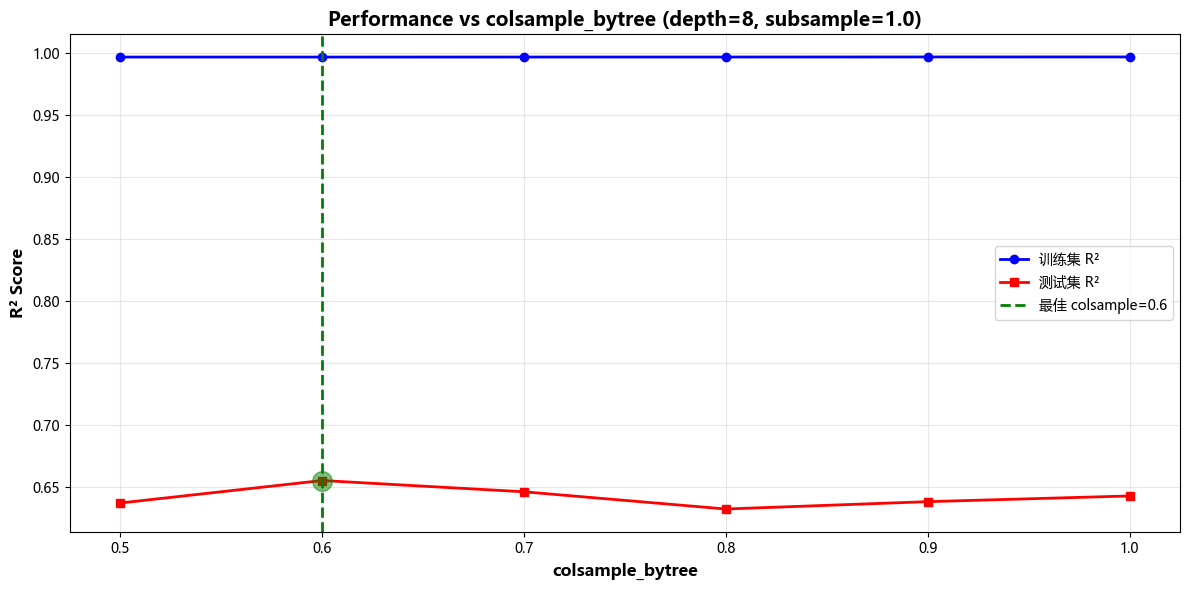


✓ colsample_bytree 分析图已保存


In [4]:
#colsample_bytree 的影响
print("\n" + "="*70)
print("实验 3：colsample_bytree 对性能的影响")
print("="*70)

# 测试不同的 colsample_bytree
colsamples = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
colsample_train_scores = []
colsample_test_scores = []

for col in colsamples:
    print(f"\n训练 colsample_bytree={col}...")
    
    model = xgb.XGBRegressor(
        max_depth=best_depth,
        subsample=best_subsample,
        colsample_bytree=col,
        n_estimators=100,
        tree_method='hist',  # 直方图算法，快 5-10 倍
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train, verbose=False)
    
    train_r2 = model.score(X_train, y_train)
    test_r2 = model.score(X_test, y_test)
    
    colsample_train_scores.append(train_r2)
    colsample_test_scores.append(test_r2)
    
    print(f"  训练集 R²: {train_r2:.4f}")
    print(f"  测试集 R²: {test_r2:.4f}")
    print(f"  差距: {train_r2 - test_r2:.4f}")

# 找到最佳 colsample_bytree
best_colsample_idx = np.argmax(colsample_test_scores)
best_colsample = colsamples[best_colsample_idx]
best_colsample_test_r2 = colsample_test_scores[best_colsample_idx]

print(f"\n最佳 colsample_bytree: {best_colsample} (测试集 R²={best_colsample_test_r2:.4f})")

# 可视化
plt.figure(figsize=(12, 6))

plt.plot(colsamples, colsample_train_scores, marker='o', linewidth=2, 
         label='训练集 R²', color='blue')
plt.plot(colsamples, colsample_test_scores, marker='s', linewidth=2, 
         label='测试集 R²', color='red')
plt.axvline(best_colsample, color='green', linestyle='--', linewidth=2,
            label=f'最佳 colsample={best_colsample}')
plt.scatter(best_colsample, best_colsample_test_r2, s=200, color='green', zorder=5, alpha=0.5)

plt.xlabel('colsample_bytree', fontsize=12, fontweight='bold')
plt.ylabel('R² Score', fontsize=12, fontweight='bold')
plt.title(f'Performance vs colsample_bytree (depth={best_depth}, subsample={best_subsample})', 
          fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/day16_xgb_colsample_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ colsample_bytree 分析图已保存")


最终验证：单参数最佳组合

单参数实验结果:
  实验1 - 最佳 max_depth: 8 (R²=0.5568)
  实验2 - 最佳 subsample: 1.0 (R²=0.6430)
  实验3 - 最佳 colsample_bytree: 0.6 (R²=0.6555)

  最终模型
  训练集 R²: 0.9967
  测试集 R²: 0.6555
  过拟合 Gap: 0.3412

3 折交叉验证: mean=0.5416, std=0.0623

======== 4 阶段对比 ========
Day 15  默认参数:              R²=0.6178
Day 16  实验1 +max_depth=8:     R²=0.5568
Day 16  实验2 +subsample=1.0:  R²=0.6430
Day 16  实验3 +colsample=0.6:  R²=0.6555
Day 16  最终组合:               R²=0.6555
相比默认提升: +0.0377 (+6.1%)


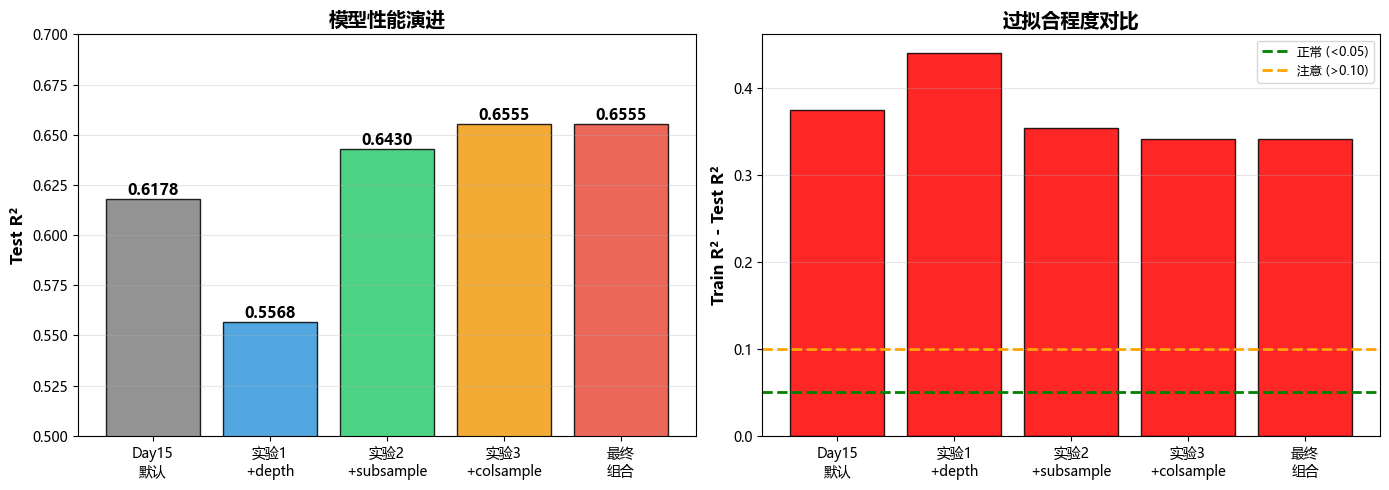


✓ 最终对比图已保存


In [8]:
#最终验证：用单参数实验找到的最佳组合，只做一次 CV 确认
print("\n" + "="*70)
print("最终验证：单参数最佳组合")
print("="*70)

# 汇总三个实验的最佳参数
print(f"\n单参数实验结果:")
print(f"  实验1 - 最佳 max_depth: {best_depth} (R²={best_test_r2:.4f})")
print(f"  实验2 - 最佳 subsample: {best_subsample} (R²={best_subsample_test_r2:.4f})")
print(f"  实验3 - 最佳 colsample_bytree: {best_colsample} (R²={best_colsample_test_r2:.4f})")

# 用最佳参数训练最终模型
final_model = xgb.XGBRegressor(
    max_depth=best_depth,
    subsample=best_subsample,
    colsample_bytree=best_colsample,
    n_estimators=100,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train, y_train)
train_r2 = final_model.score(X_train, y_train)
test_r2 = final_model.score(X_test, y_test)

print(f"\n{'='*50}")
print(f"  最终模型")
print(f"  训练集 R²: {train_r2:.4f}")
print(f"  测试集 R²: {test_r2:.4f}")
print(f"  过拟合 Gap: {train_r2 - test_r2:.4f}")
print(f"{'='*50}")

# 3 折交叉验证确认
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(final_model, X_train, y_train, cv=3, scoring='r2', n_jobs=-1)
print(f"\n3 折交叉验证: mean={cv_scores.mean():.4f}, std={cv_scores.std():.4f}")

# 对比所有阶段
print(f"\n======== 4 阶段对比 ========")
print(f"Day 15  默认参数:              R²={baseline_test_r2:.4f}")
print(f"Day 16  实验1 +max_depth={best_depth}:     R²={best_test_r2:.4f}")
print(f"Day 16  实验2 +subsample={best_subsample}:  R²={best_subsample_test_r2:.4f}")
print(f"Day 16  实验3 +colsample={best_colsample}:  R²={best_colsample_test_r2:.4f}")
print(f"Day 16  最终组合:               R²={test_r2:.4f}")
improvement = test_r2 - baseline_test_r2
print(f"相比默认提升: {improvement:+.4f} ({improvement/baseline_test_r2*100:+.1f}%)")

# 可视化：性能演进
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：各阶段测试集 R²
stages = ['Day15\n默认', '实验1\n+depth', '实验2\n+subsample', '实验3\n+colsample', '最终\n组合']
stage_r2 = [baseline_test_r2, best_test_r2, best_subsample_test_r2,
            best_colsample_test_r2, test_r2]
colors = ['gray', '#3498db', '#2ecc71', '#f39c12', '#e74c3c']
ax1 = axes[0]
bars = ax1.bar(stages, stage_r2, color=colors, alpha=0.85, edgecolor='black')
ax1.set_ylabel('Test R²', fontsize=12, fontweight='bold')
ax1.set_title('模型性能演进', fontsize=14, fontweight='bold')
ax1.set_ylim([0.5, 0.7])
ax1.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, stage_r2):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

# 右图：过拟合程度
# 重新训练各阶段模型取 train_r2
models_for_gap = {
    '默认': xgb.XGBRegressor(random_state=42, n_jobs=-1),
    '+depth': xgb.XGBRegressor(max_depth=best_depth, n_estimators=100,
                                tree_method='hist', random_state=42, n_jobs=-1),
    '+subsample': xgb.XGBRegressor(max_depth=best_depth, subsample=best_subsample,
                                    n_estimators=100, tree_method='hist',
                                    random_state=42, n_jobs=-1),
    '+colsample': xgb.XGBRegressor(max_depth=best_depth, subsample=best_subsample,
                                    colsample_bytree=best_colsample, n_estimators=100,
                                    tree_method='hist', random_state=42, n_jobs=-1),
}
train_list = []
for name, m in models_for_gap.items():
    m.fit(X_train, y_train)
    train_list.append(m.score(X_train, y_train))
train_list.append(train_r2)

gaps = [t - s for t, s in zip(train_list, stage_r2)]
gap_colors = ['green' if g < 0.05 else 'orange' if g < 0.10 else 'red' for g in gaps]
ax2 = axes[1]
ax2.bar(stages, gaps, color=gap_colors, alpha=0.85, edgecolor='black')
ax2.axhline(0.05, color='green', linestyle='--', linewidth=2, label='正常 (<0.05)')
ax2.axhline(0.10, color='orange', linestyle='--', linewidth=2, label='注意 (>0.10)')
ax2.set_ylabel('Train R² - Test R²', fontsize=12, fontweight='bold')
ax2.set_title('过拟合程度对比', fontsize=14, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../figures/day16_final_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ 最终对比图已保存")

In [10]:
# 保存调优后的模型
joblib.dump(final_model, '../models/day16_xgb_tuned_trees.pkl')
print("✓ 调优后的 XGBoost 模型已保存到 ../models/day16_xgb_tuned_trees.pkl")

# 保存调参结果
import json

tuning_summary = {
    'best_params': {
        'max_depth': int(best_depth),
        'subsample': float(best_subsample),
        'colsample_bytree': float(best_colsample)
    },
    'test_r2': float(test_r2),
    'cv_r2_mean': float(cv_scores.mean()),
    'cv_r2_std': float(cv_scores.std()),
    'baseline_test_r2': float(baseline_test_r2),
    'improvement': float(improvement),
    'individual_experiments': {
        'max_depth': {
            'values_tested': depths,
            'best_value': int(best_depth),
            'best_test_r2': float(best_test_r2)
        },
        'subsample': {
            'values_tested': subsamples,
            'best_value': float(best_subsample),
            'best_test_r2': float(best_subsample_test_r2)
        },
        'colsample_bytree': {
            'values_tested': colsamples,
            'best_value': float(best_colsample),
            'best_test_r2': float(best_colsample_test_r2)
        }
    }
}

with open('../models/day16_tree_params_tuning.json', 'w') as f:
    json.dump(tuning_summary, f, indent=2)

print("✓ 调参结果已保存到 ../models/day16_tree_params_tuning.json")

# 打印最终总结
print("\n" + "="*70)
print("Day 16 总结")
print("="*70)

print(f"\n树参数调优结果:")
print(f"  最佳 max_depth: {best_depth}")
print(f"  最佳 subsample: {best_subsample}")
print(f"  最佳 colsample_bytree: {best_colsample}")

print(f"\n性能对比:")
print(f"  基准（Day 15 默认参数）: {baseline_test_r2:.4f}")
print(f"  实验1 (depth={best_depth}):           {best_test_r2:.4f}")
print(f"  实验2 (+subsample={best_subsample}):   {best_subsample_test_r2:.4f}")
print(f"  实验3 (+colsample={best_colsample}):  {best_colsample_test_r2:.4f}")
print(f"  最终组合:                     {test_r2:.4f}")
print(f"  3 折 CV:                      {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  相比默认提升:                 {improvement:+.4f} ({improvement/baseline_test_r2*100:+.1f}%)")

print(f"\n关键发现:")
sub_comment = '无需行采样' if best_subsample == 1.0 else '行采样有效'
col_comment = '无需列采样' if best_colsample == 1.0 else '列采样有效'
print(f"  1. max_depth={best_depth} — 树深度适中，平衡了拟合和泛化")
print(f"  2. subsample={best_subsample} — {sub_comment}")
print(f"  3. colsample_bytree={best_colsample} — {col_comment}")

print("="*70)

✓ 调优后的 XGBoost 模型已保存到 ../models/day16_xgb_tuned_trees.pkl
✓ 调参结果已保存到 ../models/day16_tree_params_tuning.json

Day 16 总结

树参数调优结果:
  最佳 max_depth: 8
  最佳 subsample: 1.0
  最佳 colsample_bytree: 0.6

性能对比:
  基准（Day 15 默认参数）: 0.6178
  实验1 (depth=8):           0.5568
  实验2 (+subsample=1.0):   0.6430
  实验3 (+colsample=0.6):  0.6555
  最终组合:                     0.6555
  3 折 CV:                      0.5416 ± 0.0623
  相比默认提升:                 +0.0377 (+6.1%)

关键发现:
  1. max_depth=8 — 树深度适中，平衡了拟合和泛化
  2. subsample=1.0 — 无需行采样
  3. colsample_bytree=0.6 — 列采样有效
